In [75]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.patches import Arc
from PIL import Image
from scipy.optimize import least_squares

In [ ]:
# Draft 1 (Trash)
colors = ["red", "orange", "yellow", "green", "blue", "purple", "pink", "grey"]

fig, ax = plt.subplots()

c_x = [0,0,0,-1,-1,2,2]
c_y = [0,0,1,1,-1,-1,4]
r_sequence = [1,1,2,3,5,8,13]
q_sequence = [1, 2, 3, 4, 1, 2, 3]

scale = 1
rotation = 0

def Fibonacci_model(scale, rotation):
    for x, y, r, q, color in zip(c_x, c_y, r_sequence, q_sequence, colors):
        quarter_circle = Arc((scale * x, scale * y), 2 * scale * r, 2 * scale * r, angle = rotation, theta1 = 90 * q, theta2 = 90 * (q+1), color = color, linewidth = 2)
        ax.add_patch(quarter_circle)
        # ax.scatter(scale * x, scale * y, color = color)
                   
Fibonacci_model(scale, rotation)
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(-10, 15)
ax.set_ylim(-10, 5)
plt.title('Fibonacci Spiral')
plt.show()




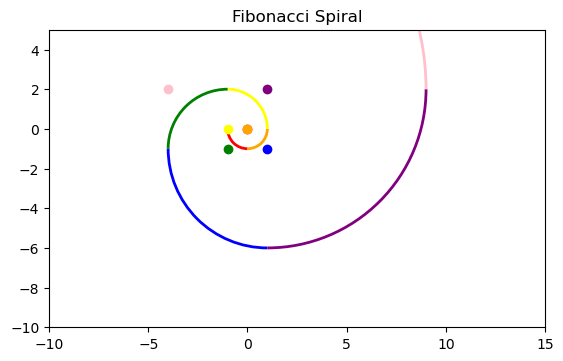

In [27]:
# Draft 2 (Trash)
colors = ["red", "orange", "yellow", "green", "blue", "purple", "pink", "grey"]

fig, ax = plt.subplots()

c_x = [0,0,0,-1,-1,2,2]
c_y = [0,0,1,1,-1,-1,4]
r_sequence = [1,1,2,3,5,8,13]
q_sequence = [1, 2, 3, 4, 1, 2, 3]

scale = 1
rotation = 90

def Fibonacci_model(scale, rotation):
    for x, y, r, q, color in zip(c_x, c_y, r_sequence, q_sequence, colors):
        quarter_circle = Arc(((scale * x) * np.cos(np.pi * (rotation / 180)) - (scale * y) * np.sin(np.pi * (rotation / 180)), (scale * x) * np.sin(np.pi * (rotation / 180)) + (scale * y) * np.cos(np.pi * (rotation / 180))), 2 * scale * r, 2 * scale * r, angle = rotation, theta1 = 90 * q, theta2 = 90 * (q+1), color = color, linewidth = 2)
        ax.add_patch(quarter_circle)
        ax.scatter((scale * x) * np.cos(np.pi * (rotation / 180)) - (scale * y) * np.sin(np.pi * (rotation / 180)), (scale * x) * np.sin(np.pi * (rotation / 180)) + (scale * y) * np.cos(np.pi * (rotation / 180)), color = color)
                   
Fibonacci_model(scale, rotation)
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(-10, 15)
ax.set_ylim(-10, 5)
plt.title('Fibonacci Spiral')
plt.show()




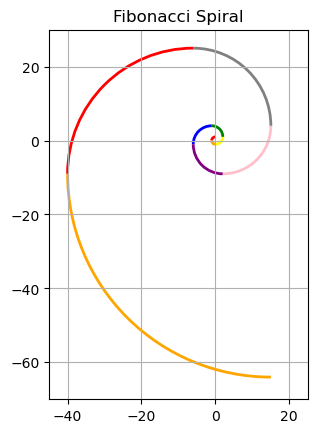

In [137]:
# Draft 3 (Working with Arc patches)
fig, ax = plt.subplots()

colors = ["red", "orange", "yellow", "green", "blue", "purple", "pink", "grey", "red", "orange"]
c_x = [0,0,0,-1,-1,2,2,-6,-6,15]
c_y = [0,0,1,1,-1,-1,4,4,-9,-9]
r_sequence = [1,1,2,3,5,8,13,21,34,55]
q_sequence = [1, 2, 3, 4, 1, 2, 3, 4, 1, 2]

o_x = 0
o_y = 0
scale = 1
rotation = 0

def Fibonacci_model(o_x, o_y, scale, rotation):
    for x, y, r, q, color in zip(c_x, c_y, r_sequence, q_sequence, colors):
        quarter_circle = Arc((((scale * x) * np.cos(np.pi * (rotation / 180)) - (scale * y) * np.sin(np.pi * (rotation / 180))) + o_x, ((scale * x) * np.sin(np.pi * (rotation / 180)) + (scale * y) * np.cos(np.pi * (rotation / 180))) + o_y), 2 * scale * r, 2 * scale * r, angle = rotation, theta1 = 90 * q, theta2 = 90 * (q+1), color = color, linewidth = 2)
        ax.add_patch(quarter_circle)
        # ax.scatter(((scale * x) * np.cos(np.pi * (rotation / 180)) - (scale * y) * np.sin(np.pi * (rotation / 180))) + o_x, ((scale * x) * np.sin(np.pi * (rotation / 180)) + (scale * y) * np.cos(np.pi * (rotation / 180))) + o_y, color = color, s = 2)
                   
Fibonacci_model(o_x, o_y, scale, rotation)
ax.grid(True)
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(-45, 25)
ax.set_ylim(-70, 30)
plt.title('Fibonacci Spiral')
plt.show()




[<matplotlib.patches.Arc object at 0x00000207A6240F50>, <matplotlib.patches.Arc object at 0x00000207A6241090>, <matplotlib.patches.Arc object at 0x00000207A62411D0>, <matplotlib.patches.Arc object at 0x00000207A6241310>, <matplotlib.patches.Arc object at 0x00000207A6241450>, <matplotlib.patches.Arc object at 0x00000207A6241590>, <matplotlib.patches.Arc object at 0x00000207A62416D0>, <matplotlib.patches.Arc object at 0x00000207A6241810>, <matplotlib.patches.Arc object at 0x00000207A6241950>, <matplotlib.patches.Arc object at 0x00000207A6241A90>]


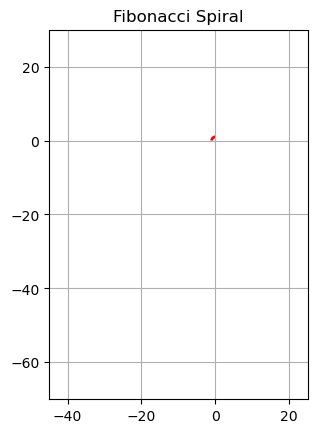

In [13]:
# Bad Revision for Curve Fitting
fig, ax = plt.subplots()

colors = ["red", "orange", "yellow", "green", "blue", "purple", "pink", "grey", "red", "orange"]
c_x = [0,0,0,-1,-1,2,2,-6,-6,15]
c_y = [0,0,1,1,-1,-1,4,4,-9,-9]
r_sequence = [1,1,2,3,5,8,13,21,34,55]
q_sequence = [1, 2, 3, 4, 1, 2, 3, 4, 1, 2]
index = range(10)

o_x = 0
o_y = 0
scale = 1
rotation = 0

def Fibonacci_model(o_x, o_y, scale, rotation):
    quarter_circle = []
    for x, y, r, q, color in zip(c_x, c_y, r_sequence, q_sequence, colors):
        quarter_circle.append(Arc((((scale * x) * np.cos(np.pi * (rotation / 180)) - (scale * y) * np.sin(np.pi * (rotation / 180))) + o_x, ((scale * x) * np.sin(np.pi * (rotation / 180)) + (scale * y) * np.cos(np.pi * (rotation / 180))) + o_y), 2 * scale * r, 2 * scale * r, angle = rotation, theta1 = 90 * q, theta2 = 90 * (q+1), color = color, linewidth = 2))
    return quarter_circle
        # ax.scatter(((scale * x) * np.cos(np.pi * (rotation / 180)) - (scale * y) * np.sin(np.pi * (rotation / 180))) + o_x, ((scale * x) * np.sin(np.pi * (rotation / 180)) + (scale * y) * np.cos(np.pi * (rotation / 180))) + o_y, color = color, s = 2)

print(Fibonacci_model(o_x, o_y, scale, rotation))

ax.add_patch(Fibonacci_model(o_x, o_y, scale, rotation)[0])
ax.grid(True)
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(-45, 25)
ax.set_ylim(-70, 30)
plt.title('Fibonacci Spiral')
plt.show()




In [34]:
# Curve Model First Attempt (Fail)
xcenter = [0,0,0,-1,-1,2,2,-6,-6,15]
ycenter = [0,0,1,1,-1,-1,4,4,-9,-9]
radius = [1,1,2,3,5,8,13,21,34,55]
index = [0,1,2,3,4,5,6,7,8]

def arcpiece(index, scale, rotation, xcenter, ycenter):
    x = radius[index] * np.cos(t) + xcenter[index]
    y = radius[index] * np.sin(t) + ycenter[index]
    return x, y



# def spiral(xorigin, yorigin):
#     for t in np.linspace(

def spiral(xorigin, yorigin, scale, rotation):
    x = []
    y = []
    for i, r, xc, yc, t in zip(index, radius, xcenter, ycenter, linspace(i * 90, (i+1) * 90, 100)) :
        x.append(arc(xc, yc, r)[0])
        y.append(arc(xc, yc, r)[1])
    return x,y

x = spiral(0,0, 1, 0)[0]
y = spiral(0,0, 1, 0)[1]

plt.figure()
plt.plot(x,y)
plt.show()

NameError: name 'linspace' is not defined

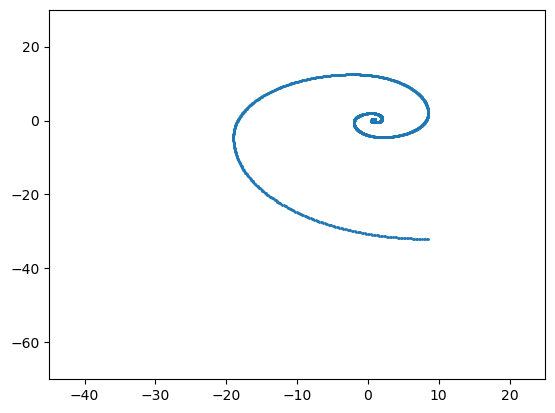

In [84]:
# Curve Model Second Attempt (Success)

xcenter = [0,0,0,-1,-1,2,2,-6,-6,15]
ycenter = [0,0,1,1,-1,-1,4,4,-9,-9]
radius = [1,1,2,3,5,8,13,21,34,55]

def spiral_model(scale, rotation, xorigin, yorigin):
    x = []
    y = []
    for i in [0,1,2,3,4,5,6,7,8,9]:
        t = np.linspace( (i + 1) * np.pi / 2, (i + 2) * np.pi / 2, 200)
        xpoint = radius[i] * np.cos(t) + xcenter[i]
        ypoint = radius[i] * np.sin(t) + ycenter[i]
        x_scal_rot_trans = (scale * xpoint * np.cos(np.pi * rotation / 180) - scale * ypoint * np.sin(np.pi * rotation / 180)) + xorigin 
        # (xcos(theta) - ysin(theta)) + xorigin
        y_scal_rot_trans = (scale * xpoint * np.sin(np.pi * rotation / 180) + scale * ypoint * np.cos(np.pi * rotation / 180)) + yorigin
        # (xsin(theta) + ycos(theta)) + yorigin
        x.append(x_scal_rot_trans)
        y.append(y_scal_rot_trans)
    return x, y


plt.figure()
plt.scatter(spiral_model(0.5,0,1,0)[0], spiral_model(0.5,0,1,0)[1], s = 1)
plt.xlim(-45, 25)
plt.ylim(-70, 30)
plt.show()


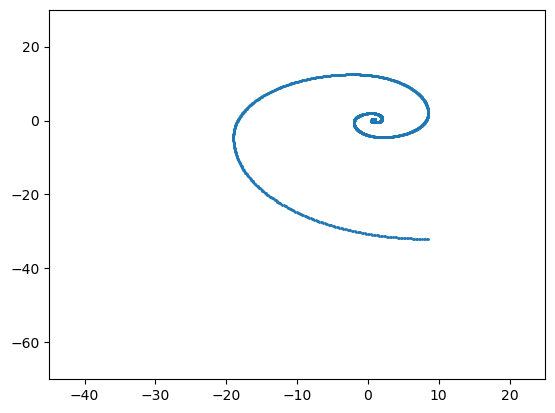

In [81]:
# Curve Model Modified

xcenter = [0,0,0,-1,-1,2,2,-6,-6,15]
ycenter = [0,0,1,1,-1,-1,4,4,-9,-9]
radius = [1,1,2,3,5,8,13,21,34,55]

def spiral_model_modified(t, scale, rotation, xorigin, yorigin):
    x = []
    y = []
    for i in [0,1,2,3,4,5,6,7,8,9]:
        timing = np.linspace( (i + 1) * np.pi / 2, (i + 2) * np.pi / 2, 200)
        if t in timing:
            xpoint = radius[i] * np.cos(t) + xcenter[i]
            ypoint = radius[i] * np.sin(t) + ycenter[i]
            x_scal_rot_trans = (scale * xpoint * np.cos(np.pi * rotation / 180) - scale * ypoint * np.sin(np.pi * rotation / 180)) + xorigin 
            # (xcos(theta) - ysin(theta)) + xorigin
            y_scal_rot_trans = (scale * xpoint * np.sin(np.pi * rotation / 180) + scale * ypoint * np.cos(np.pi * rotation / 180)) + yorigin
            # (xsin(theta) + ycos(theta)) + yorigin
            x.append(x_scal_rot_trans)
            y.append(y_scal_rot_trans)
    return x, y


plt.figure()
plt.scatter(spiral_model(0.5,0,1,0)[0], spiral_model(0.5,0,1,0)[1], s = 1)
plt.xlim(-45, 25)
plt.ylim(-70, 30)
plt.show()


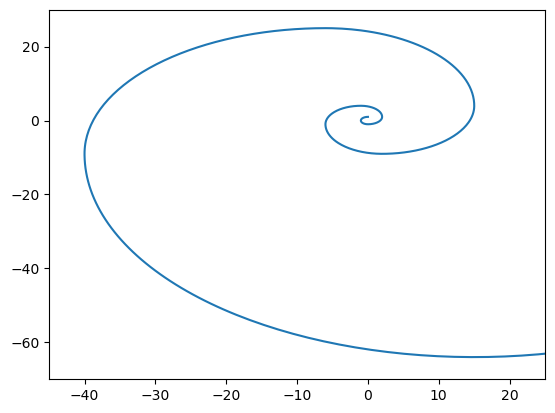

In [136]:
# Curve Model Parameterized (And it works I think!)

xcenter = [0,0,0,-1,-1,2,2,-6,-6,15]
ycenter = [0,0,1,1,-1,-1,4,4,-9,-9]
radius = [1,1,2,3,5,8,13,21,34,55]

def spiral_model_modified2(t_array, scale, rotation, xorigin, yorigin):
    x = []
    y = []
    for t in t_array:
        i = int(np.floor((t - np.pi/2) / (np.pi/2)))  
        i = max(0, min(i, len(xcenter)-1))         
        xpoint = radius[i] * np.cos(t) + xcenter[i]
        ypoint = radius[i] * np.sin(t) + ycenter[i]
        x_scal_rot_trans = (scale * xpoint * np.cos(np.pi * rotation / 180) - scale * ypoint * np.sin(np.pi * rotation / 180)) + xorigin 
        # (xcos(theta) - ysin(theta)) + xorigin
        y_scal_rot_trans = (scale * xpoint * np.sin(np.pi * rotation / 180) + scale * ypoint * np.cos(np.pi * rotation / 180)) + yorigin
        # (xsin(theta) + ycos(theta)) + yorigin
        x.append(x_scal_rot_trans)
        y.append(y_scal_rot_trans)
    return np.array(x), np.array(y)
    
timer = np.linspace(np.pi / 2, 6 * np.pi, 800)   

x, y = spiral_model_modified2(timer,1,0,0,0)

plt.figure()
plt.plot(x, y)
plt.xlim(-45, 25)
plt.ylim(-70, 30)
plt.show()


In [76]:
#Setting up for my image
plt.get_backend()
%matplotlib inline

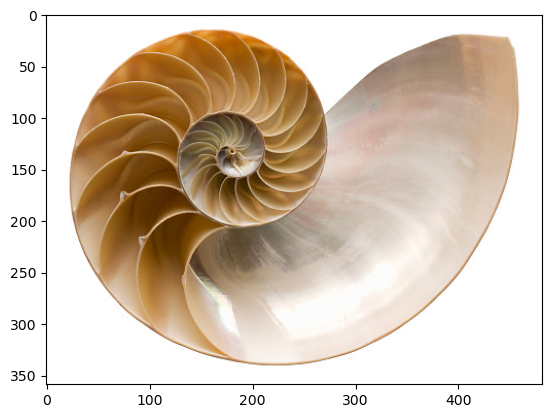

In [77]:
# Generating Base image
img = mpimg.imread("stock_nautilus_shell.jpg")   # load JPEG/PNG/etc.
plt.imshow(img)
plt.axis('on')                      # hide axis ticks
plt.show()

(359, 482, 3)


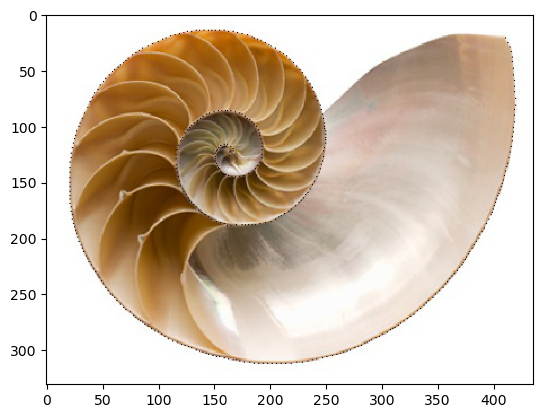

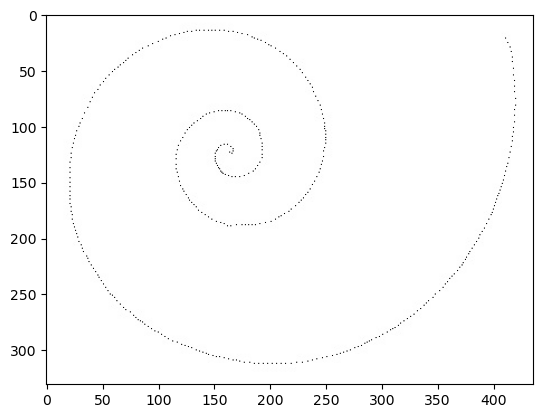

In [142]:
# Generating Marked Image

# markedimg = mpimg.imread("stock_nautilus_shell_marked.jpg")
# print(markedimg.shape)

nautilus_shell = mpimg.imread("nautilus_shell_overlay.jpg")
plt.imshow(nautilus_shell)
plt.show()

nautilus_shell_outline = mpimg.imread("outline_of_nautilus_shell.jpg")
plt.imshow(nautilus_shell_outline)
plt.show()

Found 336 green points
[[134  14]
 [137  14]
 [141  14]
 [145  14]
 [155  14]
 [159  14]
 [126  15]
 [130  15]
 [163  15]
 [167  15]]


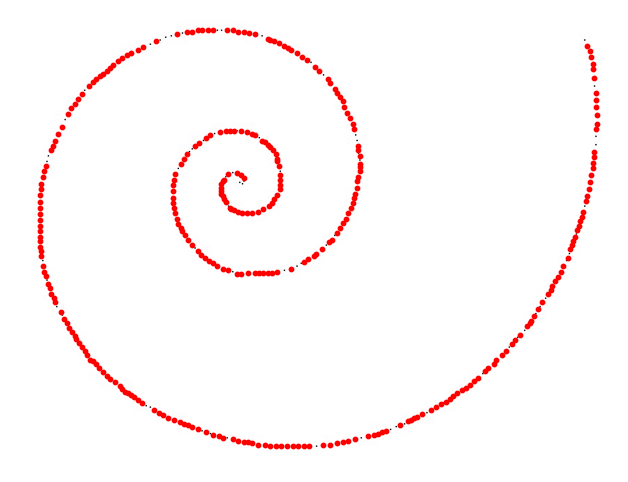

In [146]:
# Identifying marked points

target_color = np.array([0,0,0])  # RGB
tolerance = 2  # how close the pixel must be to be considered green

diff = np.abs(nautilus_shell_outline - target_color)
mask = np.all(diff < tolerance, axis=2)  # True where all channels match

coords = np.column_stack(np.where(mask))  # gives (row, col)
coords = coords[:, [1,0]]  # convert to (x, y)
print(f"Found {len(coords)} green points")
print(coords[:10])  # first 10 points

plt.figure(figsize=(8,6))
plt.imshow(nautilus_shell_outline)
plt.scatter(coords[:,0], coords[:,1], color='red', s=10)  # overlay
# plt.scatter(420,285, color = "black")
plt.axis('off')
plt.show()


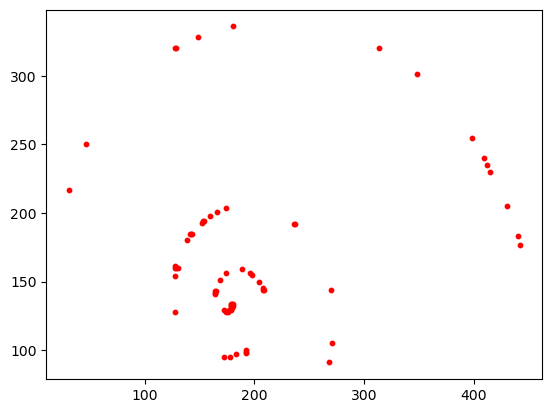

In [79]:
# Plotting marked points
plt.figure()
plt.scatter(coords[:,0], coords[:,1], color='red', s=10)
plt.show()

In [83]:
# Fitting marked points

x_data = coords[:,0]
y_data = coords[:,1]

def residuals(params, x_data, y_data):
    t, scale, rotation, xorigin, yorigin = params
    # initial guess for t (can use np.linspace)
    t_guess = np.linspace(np.pi / 2, 6 * np.pi, len(x_data))
    
    x_model, y_model = spiral_model_modified(t_guess, scale, rotation, xorigin, yorigin)
    
    # Flatten residuals for least_squares
    res = np.concatenate([x_model - x_data, y_model - y_data])
    return res

# initial guess for parameters
params0 = [1, 1, 0, 0, 0]

result = least_squares(residuals, params0, args=(x_data, y_data))
print("Fitted parameters:", result.x)


ValueError: operands could not be broadcast together with shapes (200,) (69,) 

In [ ]:
# Example Fitting
def linear_fit(x, m, b):
    # y = mx +b
    return (m * x) + b
    
def plot_fit(x, y):
    popt, pcov = curve_fit(linear_fit, x, y)
    m_fit, b_fit = popt
    plt.plot(x,y, 'b+', label = "data") # data
    plt.plot(x, m_fit*x + b_fit, color = "red", label = "Linear Fit")
    plt.title("Data to Fit")
    plt.xlabel("x values")
    plt.ylabel("y values")
    plt.legend()
    plt.show()
    print(f"Line of Best Fit: y = {m_fit:.2f}x + {b_fit:.2f}")
    perr = np.sqrt(np.diag(pcov))
    m_err, b_err = perr
    print(f"Slope: {m_fit:.2f} +/- {m_err:.2f}")
    print(f"Intercept: {b_fit:.2f} +/- {b_err:.2f}")
    residuals = y - linear_fit(x, m_fit, b_fit)
    chi2 = np.sum(residuals**2)
    dof = len(x) - len(popt)
    chi2_squared = chi2 / dof
    print(f"Reduced chi-squared: {chi2_squared:.2f}")

plot_fit(x,y)